# Final Assignment: Part 1 – Create Visualizations using Matplotlib, Seaborn & Folium

This notebook contains the completed and executed code for **Tasks 1.1–1.9**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

URL = ('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/'
       'd51iMGfp_t0QpO30Lym-dw/automobile-sales.csv')
df = pd.read_csv(URL)
print('Dataset loaded:', df.shape)

Matplotlib is building the font cache; this may take a moment.


Dataset loaded: (2112, 15)


## TASK 1.1 – Line chart: Average Annual Automobile Sales by Year

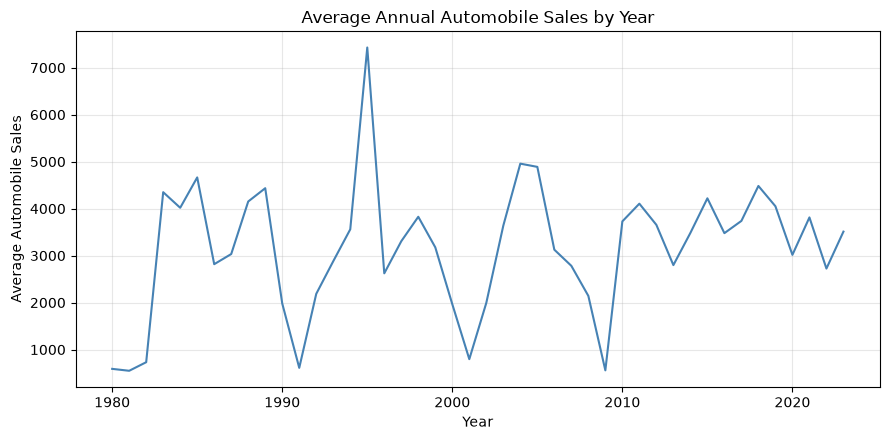

In [2]:
# TASK 1.1: Average Annual Automobile Sales from year to year
df_line = df.groupby('Year')['Automobile_Sales'].mean()
plt.figure(figsize=(9, 4.5))
df_line.plot(kind='line', color='steelblue')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Annual Automobile Sales by Year')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## TASK 1.2 – Advertising Expenditure and Automobile Sales during Non-Recession Periods

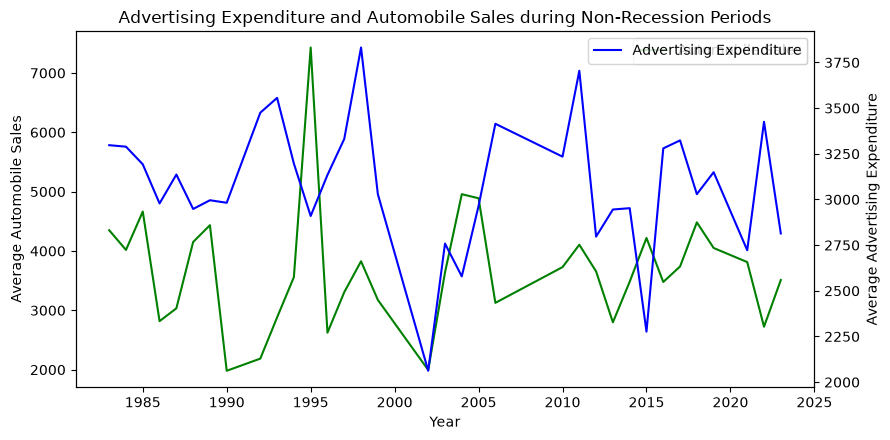

In [3]:
# TASK 1.2: Compare advertising expenditure with automobile sales in non-recession periods
df_non_rec = df[df['Recession'] == 0]
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Automobile_Sales=('Automobile_Sales', 'mean'),
    Advertising_Expenditure=('Advertising_Expenditure', 'mean'))
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
sns.lineplot(data=df_trends, x='Year', y='Automobile_Sales', ax=ax1, color='green', label='Automobile Sales')
sns.lineplot(data=df_trends, x='Year', y='Advertising_Expenditure', ax=ax2, color='blue', label='Advertising Expenditure')
ax1.set_ylabel('Average Automobile Sales')
ax2.set_ylabel('Average Advertising Expenditure')
ax1.set_title('Advertising Expenditure and Automobile Sales during Non-Recession Periods')
fig.tight_layout()
plt.show()

## TASK 1.3 – Vehicle-Wise Sales during Recession and Non-Recession Periods

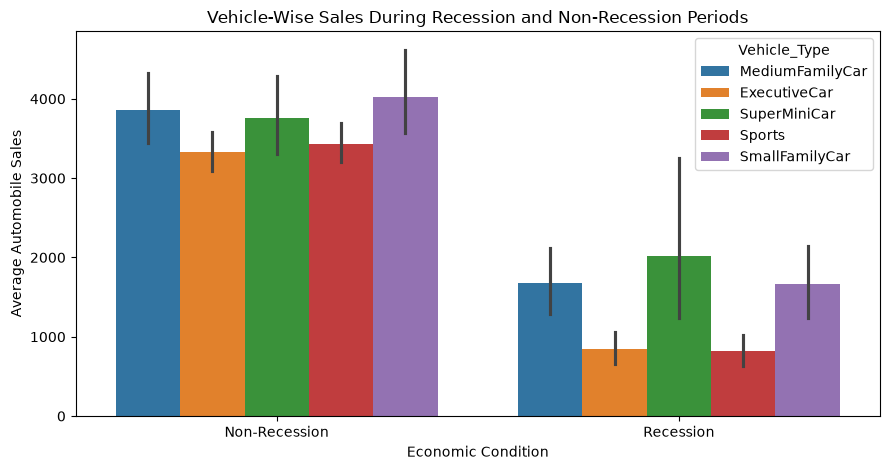

In [4]:
# TASK 1.3: Grouped bar chart by economic condition and vehicle type
plt.figure(figsize=(9, 4.8))
sns.barplot(data=df, x='Recession', y='Automobile_Sales', hue='Vehicle_Type')
plt.xticks([0, 1], ['Non-Recession', 'Recession'])
plt.xlabel('Economic Condition')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales During Recession and Non-Recession Periods')
plt.tight_layout()
plt.show()

## TASK 1.4 – GDP Variation during Recession and Non-Recession Periods

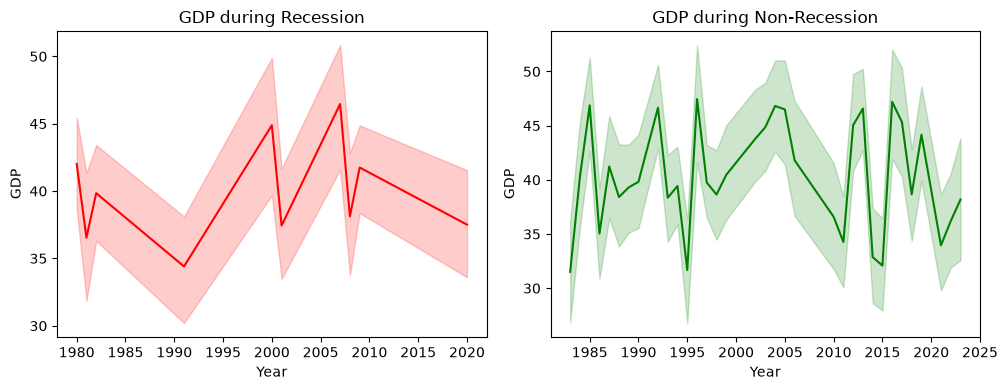

In [5]:
# TASK 1.4: Subplots comparing GDP in recession and non-recession periods
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=rec_data, x='Year', y='GDP', ax=axes[0], color='red')
axes[0].set_title('GDP during Recession')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP')
sns.lineplot(data=non_rec_data, x='Year', y='GDP', ax=axes[1], color='green')
axes[1].set_title('GDP during Non-Recession')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP')
plt.tight_layout()
plt.show()

## TASK 1.5 – Bubble Plot: Seasonality Impact on Automobile Sales

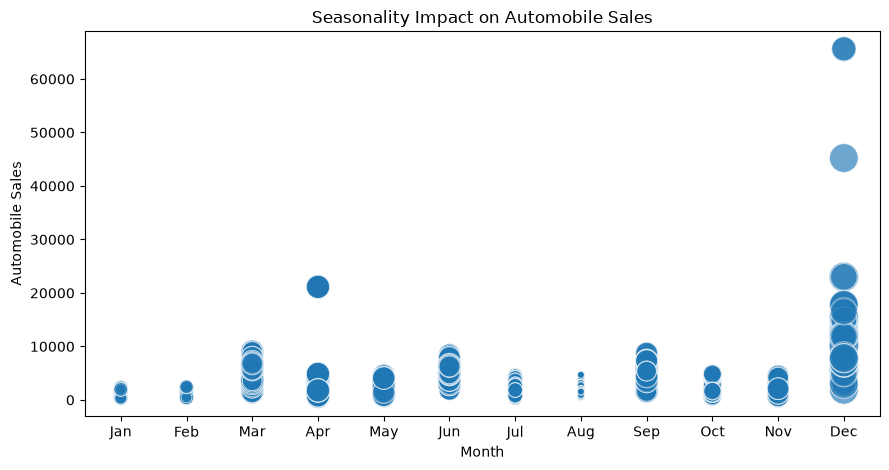

In [6]:
# TASK 1.5: Bubble plot of seasonality and automobile sales
plt.figure(figsize=(9, 4.8))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales',
                size='Seasonality_Weight', sizes=(25, 450), alpha=0.65, legend=False)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Impact on Automobile Sales')
plt.tight_layout()
plt.show()

## TASK 1.6 – Scatter Plot: Vehicle Price and Automobile Sales during Recession

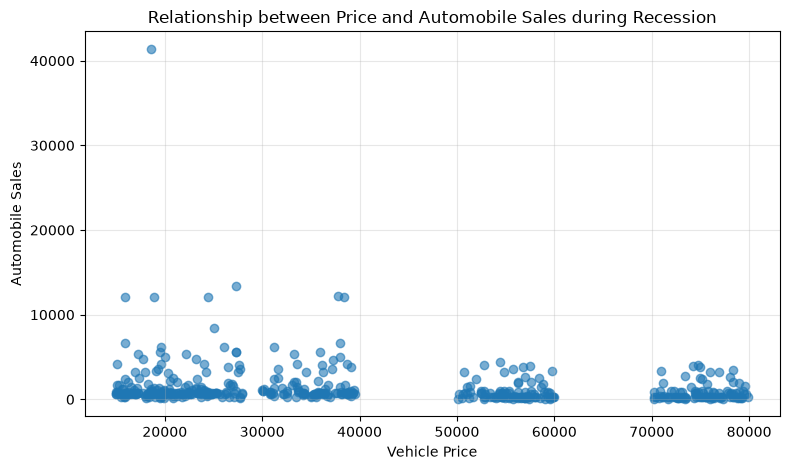

In [7]:
# TASK 1.6: Relationship between price and automobile sales during recession
plt.figure(figsize=(8, 4.8))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], alpha=0.6)
plt.xlabel('Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Price and Automobile Sales during Recession')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## TASK 1.7 – Pie Chart: Advertising Expenditure during Recession and Non-Recession Periods

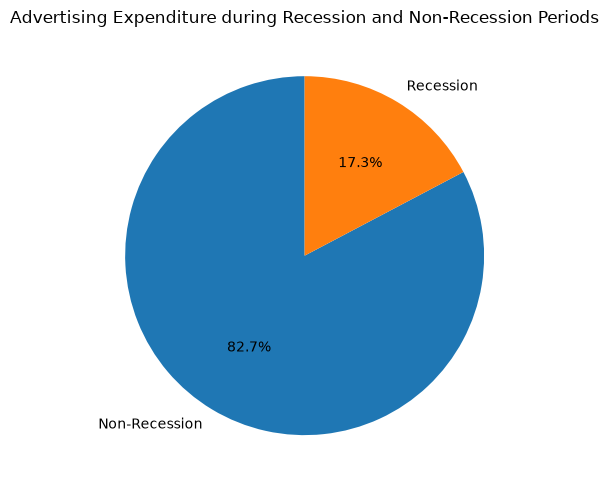

In [8]:
# TASK 1.7: Advertising expenditure distribution by economic condition
ad_by_period = df.groupby('Recession')['Advertising_Expenditure'].sum()
plt.figure(figsize=(6, 5))
plt.pie(ad_by_period.values, labels=['Non-Recession', 'Recession'], autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.tight_layout()
plt.show()

## TASK 1.8 – Pie Chart: Advertising Expenditure by Vehicle Type during Recession

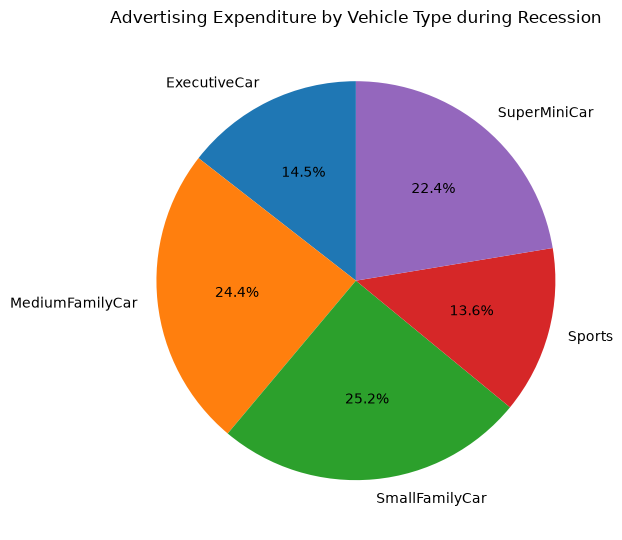

In [9]:
# TASK 1.8: Total advertising expenditure for each vehicle type during recession
vehicle_ad = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.figure(figsize=(6.5, 5.5))
plt.pie(vehicle_ad.values, labels=vehicle_ad.index, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure by Vehicle Type during Recession')
plt.tight_layout()
plt.show()

## TASK 1.9 – Unemployment Rate, Vehicle Type, and Automobile Sales during Recession

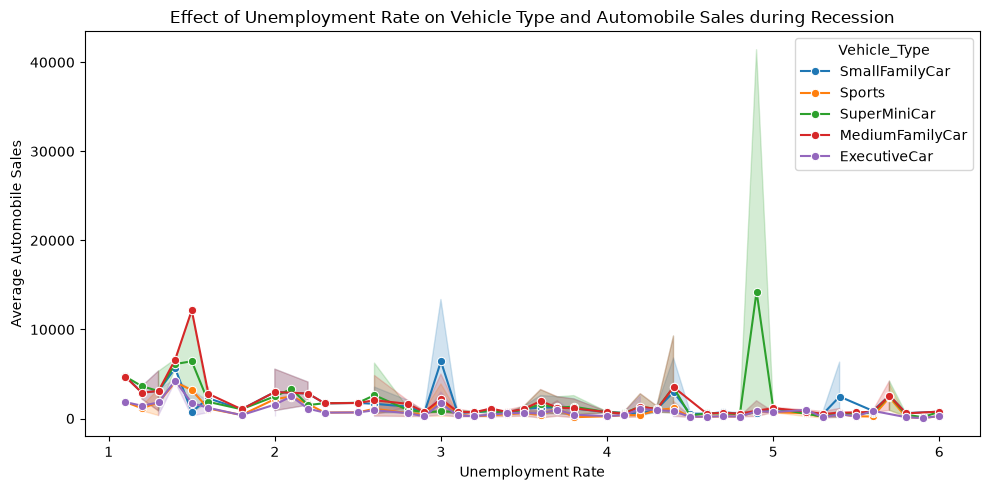

In [10]:
# TASK 1.9: Effect of unemployment rate on vehicle type and automobile sales during recession
plt.figure(figsize=(10, 5))
sns.lineplot(data=rec_data, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type', marker='o')
plt.xlabel('Unemployment Rate')
plt.ylabel('Average Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Automobile Sales during Recession')
plt.tight_layout()
plt.show()